# Bab 6 — Building Your First Deep Neural Network: Introduction to Backpropagation

Notebook ini merangkum **Bab 6** buku *Grokking Deep Learning* (Andrew W. Trask, 2019).

Bab ini adalah salah satu bab terpenting di buku: kita membangun **deep neural network pertama** (3 layer) dan mempelajari algoritma **backpropagation** — cara mendistribusikan error ke bobot-bobot di layer tersembunyi.

Isi notebook:
1. Masalah lampu penyeberangan (*the streetlight problem*)
2. Menyiapkan data: matriks & hubungan matriks
3. Membuat matriks di Python & membangun neural network
4. Mempelajari seluruh dataset
5. Full, batch, dan stochastic gradient descent
6. Neural network mempelajari korelasi — *up and down pressure*
7. Edge case: overfitting
8. Edge case: conflicting pressure
9. Learning indirect correlation & menciptakan korelasi
10. Menumpuk neural network & backpropagation
11. Linear vs nonlinear — rahasia *sometimes correlation*
12. Deep neural network pertama & backpropagation dalam kode
13. Satu iterasi backpropagation & verifikasi gradien
14. Putting it all together & mengapa deep network penting

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
np.random.seed(1)

## 1. The Streetlight Problem

Bayangkan kita berada di negara asing dan melihat lampu penyeberangan dengan **3 lampu** yang polanya tidak kita pahami. Dengan mengamati kapan orang **berjalan** atau **berhenti**, kita mencoba menebak aturannya.

| Lampu kiri | Lampu tengah | Lampu kanan | Aksi |
|:-:|:-:|:-:|:-:|
| ● | ○ | ● | STOP |
| ○ | ● | ● | WALK |
| ○ | ○ | ● | STOP |
| ● | ● | ● | WALK |
| ○ | ● | ● | WALK |
| ● | ○ | ● | STOP |

Setelah beberapa pengamatan, polanya terlihat: **lampu tengah** berkorelasi sempurna dengan WALK, lampu kiri & kanan tidak berpengaruh. Manusia bisa melihatnya — sekarang kita ajari neural network.

## 2. Menyiapkan Data

Neural network tidak memahami "lampu" — ia hanya memahami **angka**. Kita perlu dua dataset:
- **Input**: pola lampu (apa yang kita ketahui).
- **Output**: WALK/STOP (apa yang ingin kita ketahui).

Keduanya disusun sebagai **matriks**:
- Setiap **baris** = satu contoh (satu pengamatan lampu).
- Setiap **kolom** = satu variabel (satu lampu).

### Matrices and the matrix relationship
Yang penting adalah **hubungan matriks**: matriks input dan output harus **menyimpan pola yang sama** dengan dunia nyata. Pilihan encoding-nya bebas (1 = nyala, 0 = mati, atau sebaliknya; atau bahkan skala lain) asalkan **konsisten** dan **lossless** — pola aslinya bisa direkonstruksi sempurna dari matriksnya.

In [2]:
# Tiga encoding berbeda untuk data yang SAMA — semuanya mempertahankan pola
streetlights_a = np.array([[1, 0, 1], [0, 1, 1], [0, 0, 1], [1, 1, 1], [0, 1, 1], [1, 0, 1]])
streetlights_b = 1 - streetlights_a              # 1 = mati, 0 = nyala
streetlights_c = streetlights_a * 0.5            # skala berbeda

walk_vs_stop = np.array([0, 1, 0, 1, 1, 0])      # 1 = WALK, 0 = STOP

def train_linear(X, y, alpha=0.1, iters=200):
    w = np.zeros(X.shape[1] + 1)                 # +1 bias agar encoding terbalik juga bisa
    Xb = np.column_stack([X, np.ones(len(X))])
    for _ in range(iters):
        for x_, t in zip(Xb, y):
            w -= alpha * x_ * (x_.dot(w) - t)
    return Xb.dot(w)

for name, X in [('1 = nyala', streetlights_a), ('1 = mati', streetlights_b), ('nyala = 0.5', streetlights_c)]:
    print(f'Encoding {name:12s} -> prediksi {train_linear(X, walk_vs_stop).round(2)}')
print('Target                     ->', walk_vs_stop)

Encoding 1 = nyala    -> prediksi [0. 1. 0. 1. 1. 0.]
Encoding 1 = mati     -> prediksi [-0.  1.  0.  1.  1. -0.]
Encoding nyala = 0.5  -> prediksi [0. 1. 0. 1. 1. 0.]
Target                     -> [0 1 0 1 1 0]


Ketiga encoding sama-sama bisa dipelajari, karena **polanya** tetap sama.

## 3. Membuat Matriks di Python & Membangun Neural Network

In [3]:
streetlights = np.array([[1, 0, 1],
                         [0, 1, 1],
                         [0, 0, 1],
                         [1, 1, 1],
                         [0, 1, 1],
                         [1, 0, 1]])

walk_vs_stop = np.array([0, 1, 0, 1, 1, 0])
print('Input shape :', streetlights.shape, '(6 contoh x 3 lampu)')
print('Output shape:', walk_vs_stop.shape)

Input shape : (6, 3) (6 contoh x 3 lampu)
Output shape: (6,)


Pertama, latih dengan **satu contoh saja** (persis seperti Bab 5):

In [4]:
weights = np.array([0.5, 0.48, -0.7])
alpha = 0.1

input = streetlights[0]           # [1, 0, 1]
goal_prediction = walk_vs_stop[0] # 0 (STOP)

for iteration in range(20):
    prediction = input.dot(weights)
    error = (goal_prediction - prediction) ** 2
    delta = prediction - goal_prediction
    weights = weights - (alpha * (input * delta))
    if iteration % 5 == 0 or iteration == 19:
        print(f'Error: {error:.6f}  Prediction: {prediction:.4f}')

Error: 0.040000  Prediction: -0.2000
Error: 0.004295  Prediction: -0.0655
Error: 0.000461  Prediction: -0.0215
Error: 0.000050  Prediction: -0.0070
Error: 0.000008  Prediction: -0.0029


## 4. Mempelajari Seluruh Dataset

Network di atas hanya belajar untuk **satu** pola lampu. Kita butuh bobot yang bekerja untuk **semua** contoh — loop di dalam loop:

In [5]:
weights = np.array([0.5, 0.48, -0.7])
alpha = 0.1
w_hist, e_hist = [weights.copy()], []

for iteration in range(40):
    error_for_all_lights = 0
    for row_index in range(len(walk_vs_stop)):
        input = streetlights[row_index]
        goal_prediction = walk_vs_stop[row_index]

        prediction = input.dot(weights)
        error = (goal_prediction - prediction) ** 2
        error_for_all_lights += error

        delta = prediction - goal_prediction
        weights = weights - (alpha * (input * delta))
    w_hist.append(weights.copy()); e_hist.append(error_for_all_lights)
    if iteration % 10 == 0 or iteration == 39:
        print(f'Iter {iteration:2d}  Error: {error_for_all_lights:.6f}')

print('\nBobot akhir:', weights.round(4))
print('Prediksi   :', streetlights.dot(weights).round(3))

Iter  0  Error: 2.656123
Iter 10  Error: 0.043948
Iter 20  Error: 0.007869
Iter 30  Error: 0.001894
Iter 39  Error: 0.000534

Bobot akhir: [ 0.0139  1.0138 -0.016 ]
Prediksi   : [-0.002  0.998 -0.016  1.012  0.998 -0.002]


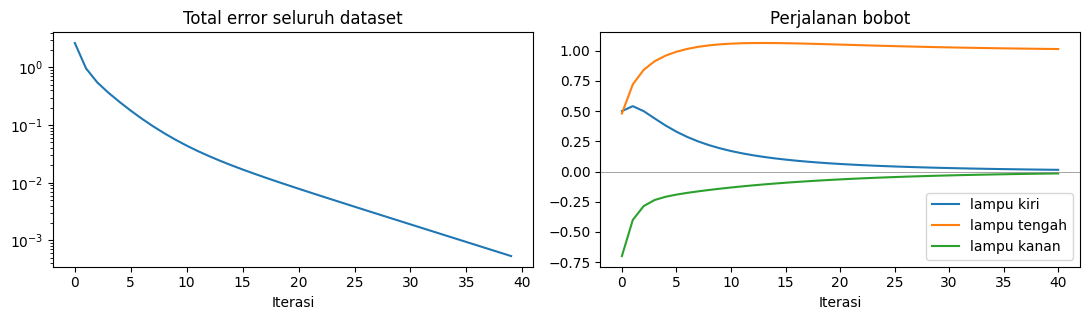

In [6]:
w_hist = np.array(w_hist)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
axes[0].plot(e_hist); axes[0].set_yscale('log')
axes[0].set_title('Total error seluruh dataset'); axes[0].set_xlabel('Iterasi')
for i, n in enumerate(['kiri', 'tengah', 'kanan']):
    axes[1].plot(w_hist[:, i], label=f'lampu {n}')
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_title('Perjalanan bobot'); axes[1].set_xlabel('Iterasi'); axes[1].legend()
plt.tight_layout(); plt.show()

Bobot lampu tengah naik mendekati **1**, sedangkan bobot lampu kiri & kanan turun mendekati **0** — network menemukan bahwa hanya lampu tengah yang prediktif.

## 5. Full, Batch, dan Stochastic Gradient Descent

| Metode | Kapan bobot di-update | Karakteristik |
|---|---|---|
| **Stochastic GD** | Setelah **setiap** contoh | Update sering & berisik; yang dipakai di atas |
| **(Average/Full) GD** | Setelah **seluruh** dataset (rata-rata weight_delta) | Stabil tapi lambat untuk dataset besar |
| **Batch (mini-batch) GD** | Setelah **n** contoh | Kompromi; standar industri (dibahas Bab 8) |

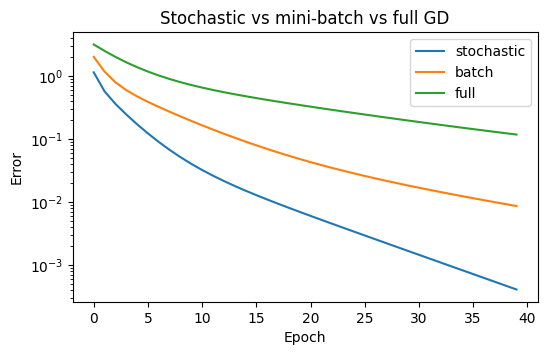

In [7]:
def train(mode, iters=40, batch_size=2, alpha=0.1):
    w = np.array([0.5, 0.48, -0.7])
    errs = []
    n = len(walk_vs_stop)
    for _ in range(iters):
        if mode == 'stochastic':
            for x, y in zip(streetlights, walk_vs_stop):
                w = w - alpha * x * (x.dot(w) - y)
        elif mode == 'full':
            delta = streetlights.dot(w) - walk_vs_stop
            w = w - alpha * streetlights.T.dot(delta) / n
        else:  # mini-batch
            for i in range(0, n, batch_size):
                xb, yb = streetlights[i:i + batch_size], walk_vs_stop[i:i + batch_size]
                w = w - alpha * xb.T.dot(xb.dot(w) - yb) / len(xb)
        errs.append(((streetlights.dot(w) - walk_vs_stop) ** 2).sum())
    return errs

plt.figure(figsize=(6, 3.5))
for mode in ['stochastic', 'batch', 'full']:
    plt.plot(train(mode), label=mode)
plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('Error'); plt.legend()
plt.title('Stochastic vs mini-batch vs full GD')
plt.show()

Dengan alpha yang sama, stochastic GD paling cepat turun per epoch karena melakukan 6 update per epoch, sedangkan full GD hanya 1 (tetapi setiap update-nya lebih "akurat").

## 6. Neural Network Mempelajari Korelasi — Up and Down Pressure

Mengapa bobot lampu tengah naik dan yang lain turun? Untuk setiap contoh, setiap bobot menerima **tekanan (pressure)**:

| Kondisi | Tekanan pada bobot |
|---|---|
| input = 1 dan output = 1 | **naik** (prediksi perlu lebih besar) |
| input = 1 dan output = 0 | **turun** (prediksi perlu lebih kecil) |
| input = 0 | **tidak ada** (weight_delta = 0 — efek *stopping*) |

Bobot yang input-nya **berkorelasi** dengan output menerima lebih banyak tekanan naik. Secara implisit, network **menghitung korelasi** antara setiap input dan output. Inilah esensi apa yang dipelajari neural network.

In [8]:
# Tabel tekanan per contoh (tanda sederhana: + naik, - turun, 0 tidak ada)
print(f'{"contoh":>8} {"kiri":>5} {"tengah":>7} {"kanan":>6} {"output":>7}')
pressure = np.zeros(3, dtype=int)
for x, y in zip(streetlights, walk_vs_stop):
    p = np.where(x == 1, 1 if y == 1 else -1, 0)
    pressure += p
    sym = {1: '+', -1: '-', 0: '0'}
    print(f'{str(x):>8} {sym[p[0]]:>5} {sym[p[1]]:>7} {sym[p[2]]:>6} {"WALK" if y else "STOP":>7}')
print(f'{"net":>8} {pressure[0]:>+5d} {pressure[1]:>+7d} {pressure[2]:>+6d}')

# Bandingkan dengan korelasi statistik
for i, n in enumerate(['kiri', 'tengah', 'kanan']):
    col = streetlights[:, i]
    if col.std() > 0:
        print(f'Korelasi lampu {n:6s} dengan WALK: {np.corrcoef(col, walk_vs_stop)[0, 1]:+.2f}')
    else:
        print(f'Korelasi lampu {n:6s} dengan WALK: tidak terdefinisi (selalu menyala)')

  contoh  kiri  tengah  kanan  output
 [1 0 1]     -       0      -    STOP
 [0 1 1]     0       +      +    WALK
 [0 0 1]     0       0      -    STOP
 [1 1 1]     +       +      +    WALK
 [0 1 1]     0       +      +    WALK
 [1 0 1]     -       0      -    STOP
     net    -1      +3     +0
Korelasi lampu kiri   dengan WALK: -0.33
Korelasi lampu tengah dengan WALK: +1.00
Korelasi lampu kanan  dengan WALK: tidak terdefinisi (selalu menyala)


Tekanan bersih lampu tengah paling positif, sejalan dengan korelasinya (+1). Lampu kanan selalu menyala sehingga korelasinya tidak terdefinisi — ia menerima tekanan naik dan turun yang saling meniadakan.

## 7. Edge Case: Overfitting

Kadang korelasi muncul **secara kebetulan**. Bayangkan network hanya dilatih dengan dua contoh di mana lampu kiri dan tengah selalu sama: `[0,0,1] → STOP` dan `[1,1,1] → WALK`. Network bisa mencapai error 0 dengan membagi "kepercayaan" antara lampu kiri dan tengah — lalu **berhenti belajar**. Saat diuji pada pola lain, ia gagal.

> *"Overfitting: the network learned a pattern that's only true for the training data."*

In [9]:
train_X = np.array([[0, 0, 1], [1, 1, 1]])
train_y = np.array([0, 1])

w = np.array([0.5, 0.48, -0.7])
for _ in range(100):
    for x, y in zip(train_X, train_y):
        w = w - 0.1 * x * (x.dot(w) - y)

print('Bobot setelah training pada 2 contoh:', w.round(3))
print('Error training:', ((train_X.dot(w) - train_y) ** 2).sum().round(6), '-> network berhenti belajar')
print('\nUji pada semua pola:')
for x, y in zip(streetlights[:4], walk_vs_stop[:4]):
    print(f'  {x} -> prediksi {x.dot(w):5.2f} | sebenarnya {"WALK" if y else "STOP"}')

Bobot setelah training pada 2 contoh: [ 0.51   0.49  -0.001]
Error training: 0.0 -> network berhenti belajar

Uji pada semua pola:
  [1 0 1] -> prediksi  0.51 | sebenarnya STOP
  [0 1 1] -> prediksi  0.49 | sebenarnya WALK
  [0 0 1] -> prediksi -0.00 | sebenarnya STOP
  [1 1 1] -> prediksi  1.00 | sebenarnya WALK


Error training = 0, tetapi untuk `[1,0,1]` dan `[0,1,1]` prediksinya ≈ 0.5 — network tidak tahu bahwa yang penting hanyalah lampu tengah, karena data training tidak pernah memisahkan kedua lampu. Solusi terbaik: **lebih banyak data yang beragam** (dan teknik regularization di Bab 8).

## 8. Edge Case: Conflicting Pressure

Lampu kanan selalu menyala, sehingga bobotnya menerima tekanan naik (saat WALK) dan turun (saat STOP) **bergantian**. Mengapa akhirnya bobot kanan menuju 0? Karena lampu tengah sudah bisa menjelaskan output dengan sempurna; setiap kali bobot kanan tidak nol, ia menambah error, sehingga tekanan bersihnya mendorong ke 0.

Ini adalah bentuk sederhana **regularization**: bobot yang tidak berguna didorong ke 0 karena bobot lain sudah menyelesaikan masalah. Masalahnya muncul jika **tidak ada** input yang bisa menyelesaikan masalah sendirian — bagian berikutnya.

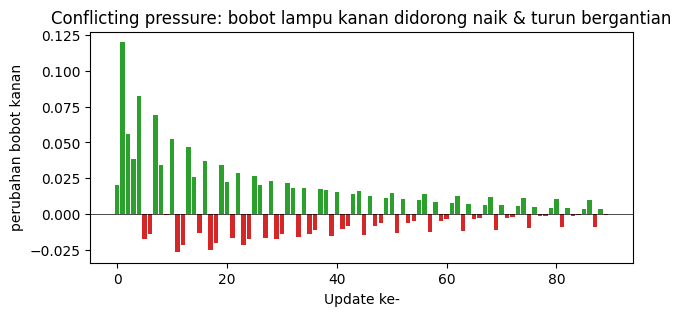

In [10]:
w = np.array([0.5, 0.48, -0.7])
right_hist = []
for epoch in range(15):
    for x, y in zip(streetlights, walk_vs_stop):
        w_before = w[2]
        w = w - 0.1 * x * (x.dot(w) - y)
        right_hist.append(w[2] - w_before)

plt.figure(figsize=(7, 3))
plt.bar(range(len(right_hist)), right_hist, color=['C2' if v > 0 else 'C3' for v in right_hist])
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('Update ke-'); plt.ylabel('perubahan bobot kanan')
plt.title('Conflicting pressure: bobot lampu kanan didorong naik & turun bergantian')
plt.show()

## 9. Learning Indirect Correlation

Bagaimana jika **tidak ada satu input pun** yang berkorelasi langsung dengan output? Contoh: WALK jika **tepat satu** dari lampu kiri atau tengah menyala (pola mirip XOR).

In [11]:
streetlights = np.array([[1, 0, 1],
                         [0, 1, 1],
                         [0, 0, 1],
                         [1, 1, 1]])
walk_vs_stop = np.array([[1, 1, 0, 0]]).T

for i, name in enumerate(['kiri', 'tengah', 'kanan']):
    x = streetlights[:, i]
    corr = np.corrcoef(x, walk_vs_stop[:, 0])[0, 1] if x.std() > 0 else 0.0
    print(f'Korelasi lampu {name:6s} dengan WALK: {corr:+.2f}')

# Network 2 layer (tanpa hidden layer) gagal
w = np.array([[0.5], [0.48], [-0.7]])
errs_2layer = []
for _ in range(200):
    total = 0
    for i in range(4):
        x = streetlights[i:i + 1]
        delta = x.dot(w) - walk_vs_stop[i:i + 1]
        total += (delta ** 2).sum()
        w -= 0.1 * x.T.dot(delta)
    errs_2layer.append(total)
print('\nPrediksi network tanpa hidden layer:', streetlights.dot(w).ravel().round(2), '(target [1 1 0 0])')
print('Error akhir:', round(errs_2layer[-1], 3))

Korelasi lampu kiri   dengan WALK: +0.00
Korelasi lampu tengah dengan WALK: +0.00
Korelasi lampu kanan  dengan WALK: +0.00

Prediksi network tanpa hidden layer: [0.44 0.39 0.44 0.39] (target [1 1 0 0])
Error akhir: 1.235


Tidak ada input yang berkorelasi langsung, sehingga network satu layer gagal (semua prediksi ≈ 0.5, error tidak pernah turun di bawah 1.0).

### Creating correlation
Solusinya: **ciptakan korelasi** dengan menambah **layer di tengah (hidden layer)**. Layer pertama mengubah input menjadi **dataset perantara** yang **memiliki** korelasi dengan output; layer kedua memakai korelasi tersebut untuk memprediksi.

## 10. Menumpuk Neural Network & Backpropagation

Arsitektur: `layer_0` (3 input) → `weights_0_1` → `layer_1` (4 hidden) → `weights_1_2` → `layer_2` (1 output).

Masalah baru: kita tahu delta di `layer_2` (prediksi − target), tetapi **berapa delta untuk `layer_1`?** Tidak ada "target" untuk hidden layer.

**Backpropagation** = *long-distance error attribution*. Delta di output dikirim **mundur** ke hidden layer melalui bobot yang sama:

$$\delta_1 = \delta_2 \, W_{12}^{\top}$$

Intuisinya: jika bobot dari hidden node ke output bernilai besar, node itu punya andil besar pada prediksi, sehingga menerima bagian error yang besar. Jika bobotnya negatif, deltanya dibalik. Jika bobotnya 0, node itu tidak disalahkan sama sekali. Inilah **weighted average error** — dan ini adalah forward propagation yang dijalankan **mundur**.

In [12]:
# Ilustrasi: delta output 0.25 dikirim mundur lewat bobot hidden->output
layer_2_delta = np.array([[0.25]])
w_12_demo = np.array([[0.0], [1.0], [-1.0], [0.5]])
print('Bobot hidden->output :', w_12_demo.ravel())
print('Delta tiap hidden    :', layer_2_delta.dot(w_12_demo.T).ravel(),
      '<- sebanding dengan andil (bobot) masing-masing')

Bobot hidden->output : [ 0.   1.  -1.   0.5]
Delta tiap hidden    : [ 0.     0.25  -0.25   0.125] <- sebanding dengan andil (bobot) masing-masing


## 11. Linear vs Nonlinear — Rahasia *Sometimes Correlation*

Tetapi menumpuk dua layer **linear** saja **tidak cukup**. Dua perkalian matriks berturut-turut setara dengan satu perkalian matriks:

$$(\mathbf{x} W_1) W_2 = \mathbf{x} (W_1 W_2) = \mathbf{x} W'$$

Akibatnya, network 3 layer linear tidak lebih kuat dari network 2 layer — setiap hidden node tetap berkorelasi dengan input secara **linear** (selalu).

**Why the neural network still doesn't work:** yang kita butuhkan adalah hidden node yang berkorelasi **kadang-kadang** (*sometimes correlation*) — aktif untuk sebagian input saja, dan diam untuk yang lain. Caranya: tambahkan fungsi **nonlinear** seperti **ReLU**, yang mematikan node ketika nilainya negatif:

$$\text{relu}(x) = \max(0, x)$$

Dengan ReLU, sebuah hidden node bisa, misalnya, "menyala hanya jika lampu kiri menyala **dan** lampu tengah mati" — korelasi bersyarat yang mustahil bagi node linear.

Dua layer : [4.2091 7.3369 3.9165 7.6294]
Satu layer: [4.2091 7.3369 3.9165 7.6294]


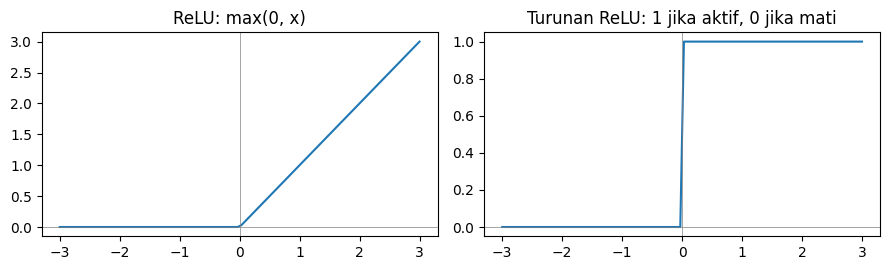

In [13]:
# Bukti: dua layer linear = satu layer linear
W1, W2 = np.random.randn(3, 4), np.random.randn(4, 1)
x = streetlights.astype(float)
print('Dua layer :', (x.dot(W1)).dot(W2).ravel().round(4))
print('Satu layer:', x.dot(W1.dot(W2)).ravel().round(4))

z = np.linspace(-3, 3, 100)
fig, axes = plt.subplots(1, 2, figsize=(9, 2.8))
axes[0].plot(z, np.maximum(0, z)); axes[0].set_title('ReLU: max(0, x)')
axes[1].plot(z, (z > 0).astype(float)); axes[1].set_title("Turunan ReLU: 1 jika aktif, 0 jika mati")
for ax in axes:
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
plt.tight_layout(); plt.show()

## 12. Deep Neural Network Pertama & Backpropagation dalam Kode

Dengan ReLU, delta yang dikirim mundur juga harus dikalikan **turunan ReLU**: node yang mati (nilai 0) tidak ikut bertanggung jawab atas error, karena mengubah bobotnya tidak akan mengubah prediksi.

$$\delta_2 = \hat{y} - y$$
$$\delta_1 = (\delta_2 \, W_{12}^{\top}) \odot \text{relu}'(\text{layer}_1)$$
$$W_{12} \mathrel{-}= \alpha \, \text{layer}_1^{\top} \delta_2, \qquad W_{01} \mathrel{-}= \alpha \, \text{layer}_0^{\top} \delta_1$$

In [14]:
np.random.seed(1)

def relu(x):
    return (x > 0) * x          # mengembalikan x jika x > 0, selain itu 0

def relu2deriv(output):
    return output > 0           # 1 jika aktif, 0 jika tidak

alpha = 0.2
hidden_size = 4

weights_0_1 = 2 * np.random.random((3, hidden_size)) - 1
weights_1_2 = 2 * np.random.random((hidden_size, 1)) - 1
init_weights = (weights_0_1.copy(), weights_1_2.copy())
history = []

for iteration in range(60):
    layer_2_error = 0
    for i in range(len(streetlights)):
        layer_0 = streetlights[i:i + 1]
        layer_1 = relu(np.dot(layer_0, weights_0_1))
        layer_2 = np.dot(layer_1, weights_1_2)

        layer_2_error += np.sum((layer_2 - walk_vs_stop[i:i + 1]) ** 2)

        layer_2_delta = layer_2 - walk_vs_stop[i:i + 1]
        layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2deriv(layer_1)

        weights_1_2 -= alpha * layer_1.T.dot(layer_2_delta)
        weights_0_1 -= alpha * layer_0.T.dot(layer_1_delta)

    history.append(layer_2_error)
    if iteration % 10 == 9:
        print(f'Error: {layer_2_error:.6f}')

Error: 0.634231
Error: 0.358384
Error: 0.083018
Error: 0.006467
Error: 0.000329
Error: 0.000015


Prediksi: [1.    0.999 0.003 0.   ] | Target: [1 1 0 0]


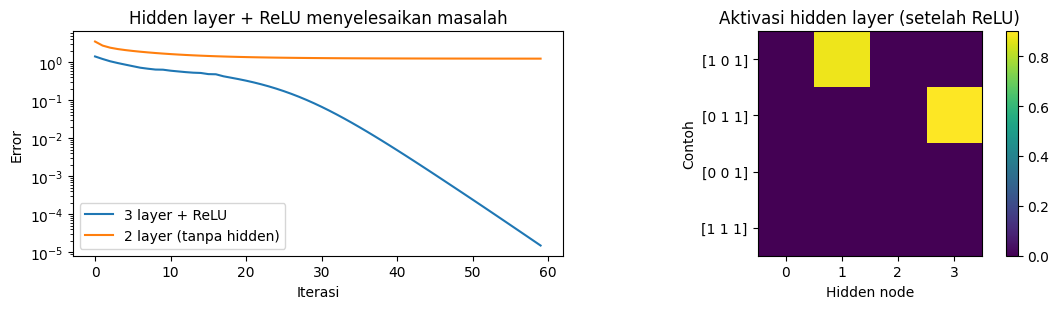

In [15]:
layer_1 = relu(streetlights.dot(weights_0_1))
pred = layer_1.dot(weights_1_2)
print('Prediksi:', pred.ravel().round(3), '| Target:', walk_vs_stop.ravel())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(history, label='3 layer + ReLU')
axes[0].plot(errs_2layer[:60], label='2 layer (tanpa hidden)')
axes[0].set_yscale('log'); axes[0].legend()
axes[0].set_xlabel('Iterasi'); axes[0].set_ylabel('Error'); axes[0].set_title('Hidden layer + ReLU menyelesaikan masalah')
im = axes[1].imshow(layer_1, cmap='viridis')
axes[1].set_xlabel('Hidden node'); axes[1].set_ylabel('Contoh')
axes[1].set_yticks(range(4), [str(r) for r in streetlights])
axes[1].set_title('Aktivasi hidden layer (setelah ReLU)')
plt.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.show()

Perhatikan peta aktivasi hidden layer: sebagian node hanya **aktif untuk sebagian contoh** (*sometimes correlation*). Hidden layer telah **menciptakan dataset perantara** yang berkorelasi dengan output — sesuatu yang mustahil dilakukan network satu layer.

### Bagaimana jika ReLU dihapus?

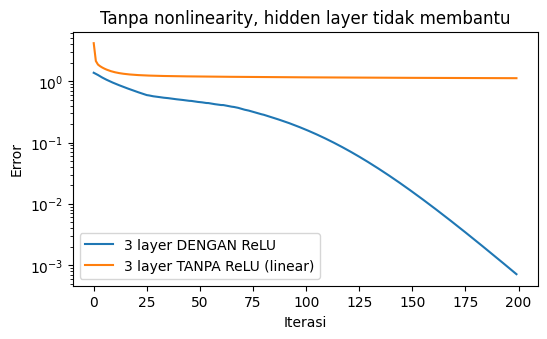

In [16]:
def train_3layer(use_relu, iters=200, seed=1):
    np.random.seed(seed)
    w01 = 2 * np.random.random((3, hidden_size)) - 1
    w12 = 2 * np.random.random((hidden_size, 1)) - 1
    act = relu if use_relu else (lambda x: x)
    dact = relu2deriv if use_relu else (lambda out: 1)
    errs = []
    for _ in range(iters):
        total = 0
        for i in range(4):
            l0 = streetlights[i:i + 1]
            l1 = act(l0.dot(w01)); l2 = l1.dot(w12)
            d2 = l2 - walk_vs_stop[i:i + 1]
            d1 = d2.dot(w12.T) * dact(l1)
            total += (d2 ** 2).sum()
            w12 -= 0.05 * l1.T.dot(d2); w01 -= 0.05 * l0.T.dot(d1)
        errs.append(total)
    return errs

plt.figure(figsize=(6, 3.3))
plt.plot(train_3layer(True), label='3 layer DENGAN ReLU')
plt.plot(train_3layer(False), label='3 layer TANPA ReLU (linear)')
plt.yscale('log'); plt.xlabel('Iterasi'); plt.ylabel('Error'); plt.legend()
plt.title('Tanpa nonlinearity, hidden layer tidak membantu')
plt.show()

Tanpa ReLU, network 3 layer terjebak di error yang sama dengan network 2 layer — bukti bahwa **nonlinearity** adalah kunci.

## 13. Satu Iterasi Backpropagation & Verifikasi Gradien

Berikut nilai setiap variabel pada **iterasi pertama** (bobot masih acak), untuk contoh pertama `[1, 0, 1]` dengan target 1:

In [17]:
weights_0_1, weights_1_2 = (w.copy() for w in init_weights)

layer_0 = streetlights[0:1]
layer_1 = relu(layer_0.dot(weights_0_1))
layer_2 = layer_1.dot(weights_1_2)
layer_2_delta = layer_2 - walk_vs_stop[0:1]
layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2deriv(layer_1)

print('layer_0 (input)    :', layer_0)
print('layer_1 (hidden)   :', layer_1.round(3))
print('layer_2 (prediksi) :', layer_2.round(3))
print('layer_2_delta      :', layer_2_delta.round(3))
print('layer_1_delta      :', layer_1_delta.round(3), '<- 0 untuk node yang dimatikan ReLU')
print('weight_delta W_1_2 :\n', layer_1.T.dot(layer_2_delta).round(3))
print('weight_delta W_0_1 :\n', layer_0.T.dot(layer_1_delta).round(3))

layer_0 (input)    : [[1 0 1]]
layer_1 (hidden)   : [[-0.     0.518 -0.    -0.   ]]
layer_2 (prediksi) : [[0.392]]
layer_2_delta      : [[-0.608]]
layer_1_delta      : [[ 0.   -0.46  0.   -0.  ]] <- 0 untuk node yang dimatikan ReLU
weight_delta W_1_2 :
 [[ 0.   ]
 [-0.315]
 [ 0.   ]
 [ 0.   ]]
weight_delta W_0_1 :
 [[ 0.   -0.46  0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.   -0.46  0.    0.  ]]


Apakah rumus backpropagation benar? Kita cek dengan **gradien numerik**: geser setiap bobot sedikit dan ukur perubahan error. Untuk error $\frac{1}{2}(\hat{y}-y)^2$, gradiennya harus sama persis dengan `layer_0.T.dot(layer_1_delta)`.

In [18]:
def half_error(w01, w12, x, y):
    return 0.5 * np.sum((relu(x.dot(w01)).dot(w12) - y) ** 2)

analytic = layer_0.T.dot(layer_1_delta)
numeric = np.zeros_like(weights_0_1)
eps = 1e-6
for i in range(weights_0_1.shape[0]):
    for j in range(weights_0_1.shape[1]):
        w_plus, w_minus = weights_0_1.copy(), weights_0_1.copy()
        w_plus[i, j] += eps; w_minus[i, j] -= eps
        numeric[i, j] = (half_error(w_plus, weights_1_2, layer_0, walk_vs_stop[0:1]) -
                         half_error(w_minus, weights_1_2, layer_0, walk_vs_stop[0:1])) / (2 * eps)

print('Gradien backprop:\n', analytic.round(6))
print('Gradien numerik :\n', numeric.round(6))
print('Selisih maksimum:', np.abs(analytic - numeric).max())

Gradien backprop:
 [[ 0.       -0.459834  0.        0.      ]
 [ 0.        0.        0.        0.      ]
 [ 0.       -0.459834  0.        0.      ]]
Gradien numerik :
 [[ 0.       -0.459834  0.        0.      ]
 [ 0.        0.        0.        0.      ]
 [ 0.       -0.459834  0.        0.      ]]
Selisih maksimum: 2.974809287792368e-11


## 14. Putting It All Together

Berikut kode lengkap versi **full batch** — keempat contoh diproses sekaligus sebagai matriks. Kodenya hampir identik; hanya `layer_0` sekarang berisi semua baris.

In [19]:
np.random.seed(1)
alpha, hidden_size = 0.2, 4
weights_0_1 = 2 * np.random.random((3, hidden_size)) - 1
weights_1_2 = 2 * np.random.random((hidden_size, 1)) - 1

for iteration in range(300):
    layer_0 = streetlights                                   # (4, 3)
    layer_1 = relu(layer_0.dot(weights_0_1))                 # (4, 4)
    layer_2 = layer_1.dot(weights_1_2)                       # (4, 1)

    layer_2_delta = (layer_2 - walk_vs_stop) / len(layer_0)  # rata-rata delta dalam batch
    layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2deriv(layer_1)

    weights_1_2 -= alpha * layer_1.T.dot(layer_2_delta)
    weights_0_1 -= alpha * layer_0.T.dot(layer_1_delta)
    if iteration % 50 == 49:
        print(f'Iter {iteration + 1:3d}  Error: {np.sum((layer_2 - walk_vs_stop) ** 2):.6f}')

print('Prediksi akhir:', relu(streetlights.dot(weights_0_1)).dot(weights_1_2).ravel().round(3))

Iter  50  Error: 0.435297
Iter 100  Error: 0.166536
Iter 150  Error: 0.019041
Iter 200  Error: 0.000923
Iter 250  Error: 0.000034
Iter 300  Error: 0.000001
Prediksi akhir: [1.    1.    0.001 0.   ]


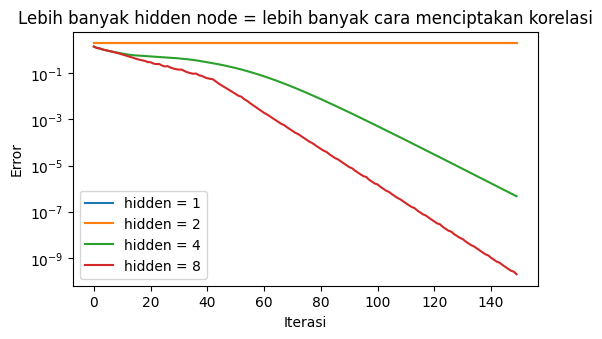

In [20]:
# Pengaruh jumlah hidden node
plt.figure(figsize=(6, 3.3))
for h in [1, 2, 4, 8]:
    np.random.seed(1)
    w01 = 2 * np.random.random((3, h)) - 1
    w12 = 2 * np.random.random((h, 1)) - 1
    errs = []
    for _ in range(150):
        total = 0
        for i in range(4):
            l0 = streetlights[i:i + 1]
            l1 = relu(l0.dot(w01)); l2 = l1.dot(w12)
            d2 = l2 - walk_vs_stop[i:i + 1]
            d1 = d2.dot(w12.T) * relu2deriv(l1)
            total += (d2 ** 2).sum()
            w12 -= 0.1 * l1.T.dot(d2); w01 -= 0.1 * l0.T.dot(d1)
        errs.append(total)
    plt.plot(errs, label=f'hidden = {h}')
plt.yscale('log'); plt.xlabel('Iterasi'); plt.ylabel('Error'); plt.legend()
plt.title('Lebih banyak hidden node = lebih banyak cara menciptakan korelasi')
plt.show()

Dengan 1 hidden node, network tidak cukup fleksibel untuk pola XOR; dengan beberapa node, ia selalu bisa menemukan kombinasi korelasi perantara yang dibutuhkan (hasil persisnya bergantung pada inisialisasi acak).

### Mengapa deep network penting?
Setiap layer membangun representasi yang lebih abstrak dari layer sebelumnya. Pada gambar, layer awal mendeteksi **tepi**, layer berikutnya **bentuk** (kombinasi tepi), lalu **bagian objek**, dan akhirnya **objek**. Kemampuan menciptakan korelasi perantara inilah yang membuat deep learning sangat kuat: semakin rumit hubungan input–output, semakin banyak "dataset perantara" yang dibutuhkan untuk menjembataninya.

## Latihan

1. Ubah aturan lampu menjadi **WALK jika lampu kiri DAN tengah menyala** (`[0, 0, 0, 1]` untuk 4 pola di atas). Apakah network 2 layer (tanpa hidden) bisa mempelajarinya?
2. Pada network 3 layer, ganti ReLU dengan **sigmoid** $\sigma(x) = 1/(1+e^{-x})$ (turunannya `out * (1 - out)`). Apakah network tetap bisa mempelajari pola XOR?

### Contoh solusi

In [21]:
# Latihan 1: AND (dengan bias lewat lampu kanan yang selalu menyala) bisa dipelajari secara linear
target_and = np.array([[0, 0, 0, 1]]).T
w = np.array([[0.5], [0.48], [-0.7]])
for _ in range(500):
    for i in range(4):
        x = streetlights[i:i + 1]
        w -= 0.1 * x.T.dot(x.dot(w) - target_and[i:i + 1])
print('AND, 2 layer -> prediksi:', streetlights.dot(w).ravel().round(2), '(target [0 0 0 1])')
print('Korelasi langsung ada (lampu kiri & tengah sama-sama +), jadi network linear cukup mendekati.')

# Latihan 2: sigmoid sebagai nonlinearity
sigmoid = lambda x: 1 / (1 + np.exp(-x))
np.random.seed(1)
w01 = 2 * np.random.random((3, 4)) - 1
w12 = 2 * np.random.random((4, 1)) - 1
for _ in range(2000):
    for i in range(4):
        l0 = streetlights[i:i + 1]
        l1 = sigmoid(l0.dot(w01)); l2 = l1.dot(w12)
        d2 = l2 - walk_vs_stop[i:i + 1]
        d1 = d2.dot(w12.T) * l1 * (1 - l1)
        w12 -= 0.2 * l1.T.dot(d2); w01 -= 0.2 * l0.T.dot(d1)
print('\nXOR, 3 layer + sigmoid -> prediksi:', sigmoid(streetlights.dot(w01)).dot(w12).ravel().round(3))

AND, 2 layer -> prediksi: [ 0.28  0.31 -0.22  0.81] (target [0 0 0 1])
Korelasi langsung ada (lampu kiri & tengah sama-sama +), jadi network linear cukup mendekati.

XOR, 3 layer + sigmoid -> prediksi: [ 1.  1. -0.  0.]


## Rangkuman Bab 6

- Data diubah menjadi **matriks** (baris = contoh, kolom = variabel); encoding bebas asalkan **polanya** tetap terjaga (*matrix relationship*).
- Network harus dilatih pada **seluruh dataset**; **stochastic GD** update per contoh, **full GD** per dataset, **mini-batch** di antaranya.
- Neural network mempelajari **korelasi** lewat *up and down pressure* pada bobot; input 0 tidak memberi tekanan.
- **Overfitting**: korelasi kebetulan di data training membuat error 0 tetapi gagal di pola baru. **Conflicting pressure**: bobot yang tidak berguna didorong ke 0 jika bobot lain sudah menyelesaikan masalah.
- Jika tidak ada korelasi langsung, butuh **hidden layer** untuk **menciptakan korelasi** (dataset perantara).
- Dua layer linear = satu layer linear → butuh **nonlinearity** seperti **ReLU** agar hidden node bisa berkorelasi *kadang-kadang*.
- **Backpropagation**: `layer_1_delta = layer_2_delta · W_12ᵀ ⊙ relu'(layer_1)` — error didistribusikan mundur sebanding dengan bobot; kebenarannya bisa diverifikasi dengan **gradien numerik**.